# Свёрточная нейронная сеть (CNN) для классификации дорожных знаков RTSD

**Датасет:** [RTSD Cleaned](https://huggingface.co/datasets/eleldar/rtsd_cleaned) — реальные фотографии дорожных знаков России  
**Фреймворк:** PyTorch с ускорением на Apple Silicon (MPS)

## Постановка задачи

Цель — построить CNN-классификатор дорожных знаков, исследовать:
- Базовую точность на чистых изображениях
- Устойчивость к искажениям (шум, размытие, окклюзия)
- Влияние аугментаций, регуляризации и функций активации
- Визуализацию ошибок через Grad-CAM / Saliency maps

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, random_split
from datasets import load_dataset
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Apple Silicon (MPS) / CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Устройство: {device}')
print(f'PyTorch версия: {torch.__version__}')

Устройство: mps
PyTorch версия: 2.10.0


## Загрузка и подготовка датасета RTSD

Предобработка:
- Ресайз до **48×48** (компромисс между деталями и скоростью)
- Нормализация по статистике датасета
- Аугментации только для train (flip, crop, jitter, rotation)

In [2]:
# Загружаем датасет через HuggingFace Datasets
# При первом запуске скачается ~несколько сотен МБ
raw = load_dataset('eleldar/rtsd_cleaned')
print(raw)

# Проверяем структуру
# Поля датасета: 'image', 'sign_class' (int id), 'sign_id' (str название знака)
sample = raw['train'][0]
print(f"\nПоля: {list(sample.keys())}")
print(f"Тип изображения: {type(sample['image'])}")
print(f"Пример sign_class: {sample['sign_class']}, sign_id: {sample['sign_id']}")

# Быстро строим маппинг через pandas (не итерируем по всем 104к элементам)
import pandas as pd
df_meta = pd.DataFrame({'sign_class': raw['train']['sign_class'],
                         'sign_id':    raw['train']['sign_id']})
df_unique = df_meta.drop_duplicates().sort_values("sign_class").reset_index(drop=True)

# orig_to_new: исходный sign_class -> плотный индекс [0, N)
orig_to_new  = {row.sign_class: i for i, row in df_unique.iterrows()}
CLASS_NAMES = [str(x) for x in df_unique["sign_id"]]   # название по новому индексу
NUM_CLASSES  = len(CLASS_NAMES)

print(f"\nЧисло классов: {NUM_CLASSES}")
print(f"Примеры классов: {CLASS_NAMES[:10]} ...")


DatasetDict({
    train: Dataset({
        features: ['image', 'sign_class', 'sign_id'],
        num_rows: 104358
    })
})

Поля: ['image', 'sign_class', 'sign_id']
Тип изображения: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Пример sign_class: 2_1, sign_id: 0

Число классов: 15628
Примеры классов: ['10981', '10982', '10985', '10986', '11029', '11030', '11039', '11040', '11467', '11468'] ...


In [3]:
IMG_SIZE = 48

# Статистика RTSD (приближённая — можно пересчитать на датасете)
MEAN = (0.485, 0.456, 0.406)  # используем ImageNet stats — хорошая инициализация
STD  = (0.229, 0.224, 0.225)

# Трансформации для обучения (с аугментациями)
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.RandomHorizontalFlip(p=0.3),          # небольшой flip (не все знаки симметричны!)
    # transforms.RandomRotation(degrees=10),             # небольшой поворот
    # transforms.ColorJitter(brightness=0.3,
    #                        contrast=0.3,
    #                        saturation=0.2),            # изменение яркости/контраста
    # transforms.RandomCrop(IMG_SIZE, padding=4),        # случайный кроп
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Трансформации для теста (только нормализация)
transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [5]:
from torch.utils.data import Dataset

from torch.utils.data import Dataset, random_split

class RTSDDataset(Dataset):
    """Обёртка над HuggingFace Dataset для совместимости с PyTorch DataLoader.
    
    sign_class — оригинальный int-id из датасета, может быть не 0-based.
    orig_to_new — маппинг в плотный диапазон [0, NUM_CLASSES).
    """
    def __init__(self, hf_split, transform=None, label_map=None):
        self.data = hf_split
        self.transform = transform
        self.label_map = label_map  # dict: orig_sign_class -> new_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item['image'].convert('RGB')
        orig_label = item['sign_class']
        label = self.label_map[orig_label] if self.label_map else orig_label
        if self.transform:
            image = self.transform(image)
        return image, label


# Датасет содержит только train split — делим 90/10
full_dataset_train = RTSDDataset(raw['train'], transform=transform_train, label_map=orig_to_new)
full_dataset_test  = RTSDDataset(raw['train'], transform=transform_test,  label_map=orig_to_new)

n_total = len(raw['train'])
n_train = int(0.9 * n_total)
n_test  = n_total - n_train

# Фиксируем сид для воспроизводимости
generator = torch.Generator().manual_seed(42)
train_indices, test_indices = random_split(range(n_total), [n_train, n_test], generator=generator)

from torch.utils.data import Subset
train_dataset = Subset(full_dataset_train, train_indices.indices)
test_dataset  = Subset(full_dataset_test,  test_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'Всего изображений: {n_total}')
print(f'Train: {n_train} изображений (90%)')
print(f'Test:  {n_test}  изображений (10%)')
print(f'Классов: {NUM_CLASSES}')

Всего изображений: 104358
Train: 93922 изображений (90%)
Test:  10436  изображений (10%)
Классов: 15628


## Визуализация данных

Посмотрим на несколько примеров из обучающей выборки, чтобы понять разнообразие датасета.

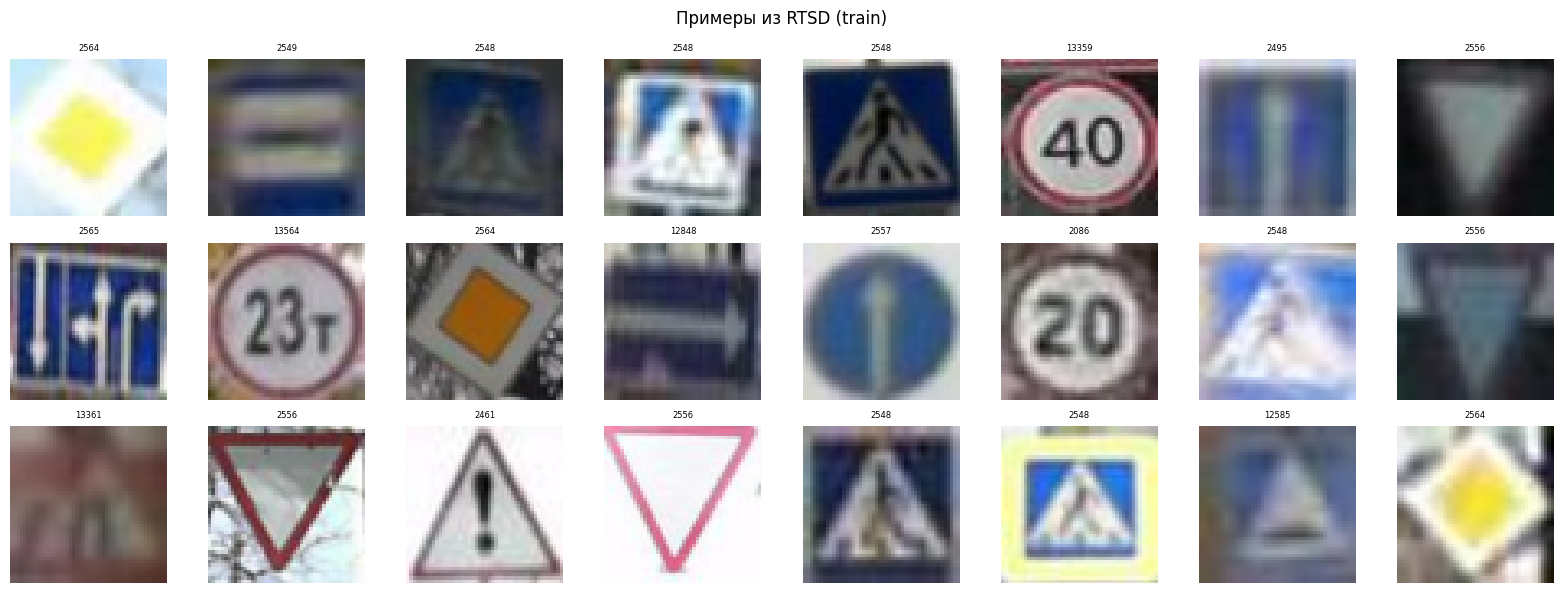

In [6]:
# Денормализация для отображения
def denormalize(tensor, mean=MEAN, std=STD):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return torch.clamp(tensor * s + m, 0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=6, wrap=True)
    ax.axis('off')
plt.suptitle('Примеры из RTSD (train)', fontsize=12)
plt.tight_layout()
plt.show()

### Распределение по классам

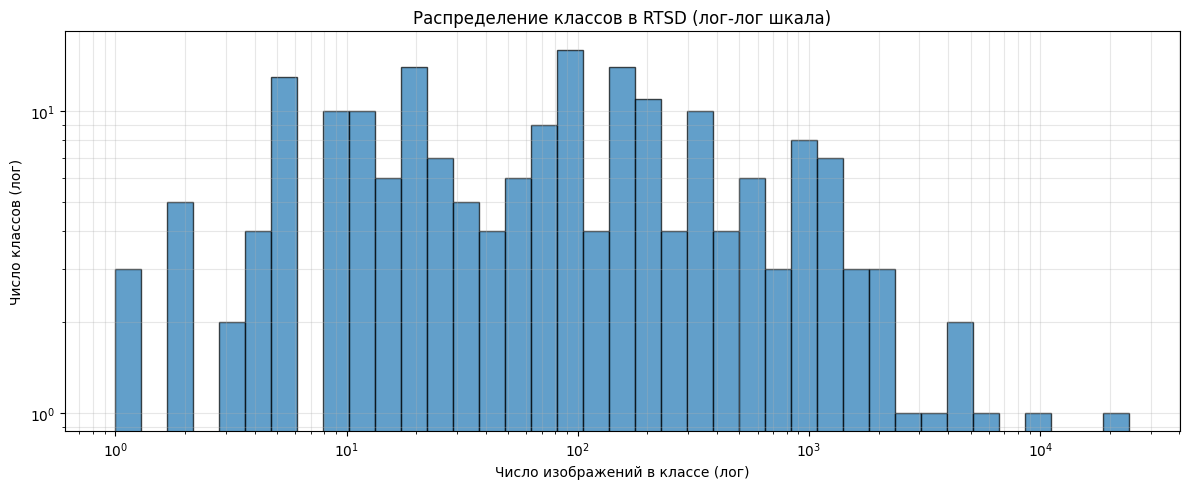

Классов: 198, Изображений: 104358
Медиана: 84, Среднее: 527.1
Классов с < 50 примеров: 83 (41.9%)


In [11]:
from collections import Counter

label_counts = Counter(orig_to_new[x] for x in raw['train']['sign_class'])
counts = np.array(list(label_counts.values()))

plt.figure(figsize=(12, 5))

# Гистограмма с лог-шкалой
plt.hist(counts, bins=np.logspace(0, np.log10(counts.max()+1), 40), 
         edgecolor='black', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Число изображений в классе (лог)')
plt.ylabel('Число классов (лог)')
plt.title('Распределение классов в RTSD (лог-лог шкала)')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"Классов: {len(counts)}, Изображений: {counts.sum()}")
print(f"Медиана: {np.median(counts):.0f}, Среднее: {counts.mean():.1f}")
print(f"Классов с < 50 примеров: {(counts < 50).sum()} ({(counts < 50).mean()*100:.1f}%)")

## Архитектура CNN

### Математика свёрточного слоя

Свёрточный слой применяет фильтр $W \in \mathbb{R}^{C_{out} \times C_{in} \times k \times k}$ к входному тензору:

$$y[c_{out}, h, w] = \sum_{c_{in}} \sum_{i=0}^{k-1} \sum_{j=0}^{k-1} W[c_{out}, c_{in}, i, j] \cdot x[c_{in}, h+i, w+j] + b[c_{out}]$$

Размер выхода при padding $p$ и stride $s$:
$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

### Batch Normalization

Нормализует активации внутри мини-батча, ускоряет сходимость и позволяет использовать большие learning rate:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma\hat{x} + \beta$$

### Функции активации (сравниваем)

- **ReLU**: $f(x) = \max(0, x)$ — быстрая, но может «умирать» (dead neurons)
- **LeakyReLU**: $f(x) = \max(\alpha x, x)$ — не умирает при $\alpha = 0.1$
- **Sigmoid**: $f(x) = \frac{1}{1+e^{-x}}$ — ванишинг-градиент, устарела для скрытых слоёв

### Архитектура: 3 блока Conv + Classifier

```markdown
Input: 3 × 48 × 48
  → Block1: Conv(3→32) × 2 + BN + ReLU + Pool(2) → 32 × 24 × 24
  → Block2: Conv(32→64) × 2 + BN + ReLU + Pool(2) → 64 × 12 × 12
  → Block3: Conv(64→128) × 2 + BN + ReLU + Pool(2) → 128 × 6 × 6
  → Flatten → 4608
  → Linear(4608→512) → ReLU → Dropout
  → Linear(512→NUM_CLASSES)
```

In [8]:
class RTSD_CNN(nn.Module):
    """CNN для классификации дорожных знаков RTSD.
    
    Три сверточных блока с двойными свёртками, BatchNorm и Dropout,
    затем полносвязный классификатор.
    """
    def __init__(self, num_classes=NUM_CLASSES, activation='relu'):
        super(RTSD_CNN, self).__init__()
        self.activation_name = activation

        def get_act():
            if activation == 'relu':
                return nn.ReLU(inplace=True)
            elif activation == 'leaky':
                return nn.LeakyReLU(0.1, inplace=True)
            elif activation == 'sigmoid':
                return nn.Sigmoid()
            else:
                raise ValueError(f'Неизвестная активация: {activation}')

        # Блок 1: 3 → 32 каналов, 48×48 → 24×24
        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            get_act(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            get_act(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Блок 2: 32 → 64 каналов, 24×24 → 12×12
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            get_act(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            get_act(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Блок 3: 64 → 128 каналов, 12×12 → 6×6
        self.block3 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            get_act(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            get_act(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Global Average Pooling вместо Flatten — меньше параметров, лучше обобщение
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            get_act(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model = RTSD_CNN(num_classes=NUM_CLASSES, activation='relu').to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nВсего параметров:     {total_params:,}')
print(f'Обучаемых параметров: {trainable:,}')

RTSD_CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, p

# Оценка производительности

Сначала оценим теоретически, затем сделаем реальные замеры и сравним с вычислительной мощностью устройства (Apple Silicon M2 4+4 CPU/ 8 GPU)

In [84]:
from fvcore.nn import FlopCountAnalysis, parameter_count_table
dummy = torch.zeros(1, 3, 48, 48).to(device)
model.eval()
flops = FlopCountAnalysis(model, dummy)
print(flops.total()*2) 

Unsupported operator aten::max_pool2d encountered 3 time(s)
Unsupported operator aten::feature_dropout encountered 3 time(s)


182959104


In [27]:
from torchinfo import summary

model.eval()
summary(
    model,
    input_size=(1, 3, 48, 48),   # batch=1, inference
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
    verbose=1
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
RTSD_CNN                                 [1, 3, 48, 48]            [1, 15628]                --                        --
├─Sequential: 1-1                        [1, 3, 48, 48]            [1, 32, 24, 24]           --                        --
│    └─Conv2d: 2-1                       [1, 3, 48, 48]            [1, 32, 48, 48]           896                       2,064,384
│    └─BatchNorm2d: 2-2                  [1, 32, 48, 48]           [1, 32, 48, 48]           64                        64
│    └─ReLU: 2-3                         [1, 32, 48, 48]           [1, 32, 48, 48]           --                        --
│    └─Conv2d: 2-4                       [1, 32, 48, 48]           [1, 32, 48, 48]           9,248                     21,307,392
│    └─BatchNorm2d: 2-5                  [1, 32, 48, 48]           [1, 32, 48, 48]           64                        64
│ 

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
RTSD_CNN                                 [1, 3, 48, 48]            [1, 15628]                --                        --
├─Sequential: 1-1                        [1, 3, 48, 48]            [1, 32, 24, 24]           --                        --
│    └─Conv2d: 2-1                       [1, 3, 48, 48]            [1, 32, 48, 48]           896                       2,064,384
│    └─BatchNorm2d: 2-2                  [1, 32, 48, 48]           [1, 32, 48, 48]           64                        64
│    └─ReLU: 2-3                         [1, 32, 48, 48]           [1, 32, 48, 48]           --                        --
│    └─Conv2d: 2-4                       [1, 32, 48, 48]           [1, 32, 48, 48]           9,248                     21,307,392
│    └─BatchNorm2d: 2-5                  [1, 32, 48, 48]           [1, 32, 48, 48]           64                        64
│ 

Unsupported operator aten::max_pool2d encountered 3 time(s)
Unsupported operator aten::feature_dropout encountered 3 time(s)


Устройство:          MPS
Эфф. пропускная сп.: 1.383 TFLOP/s
MFU:                 48.7%
Pearson r:           1.0000
R²:                  0.9999

 batch_size    time_ms  time_std_ms  time_p99_ms  ideal_ms  efficiency_pct
          1   1.854709     0.528413     3.073366  0.064422        3.473441
          4   1.694041     0.546303     3.285478  0.257689       15.211486
          8   2.045270     0.699507     4.502266  0.515378       25.198513
         16   3.067458     0.318723     4.260300  1.030756       33.602922
         32   5.234667     0.111075     5.605383  2.061511       39.381894
         64   9.825291     0.279754    10.725303  4.123022       41.963356
        128  18.792979     0.401676    20.467646  8.246044       43.878324
        256  35.704500     0.483921    37.623615 16.492088       46.190503
        512  68.688084     2.501358    77.669616 32.984176       48.020231
       1024 136.812792     2.278926   140.530348 65.968353       48.217971


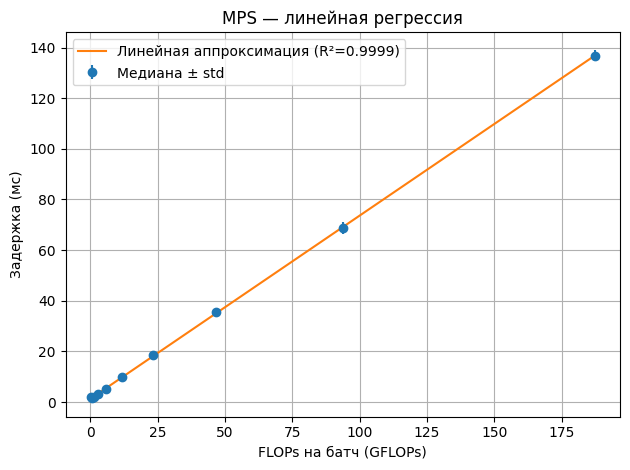

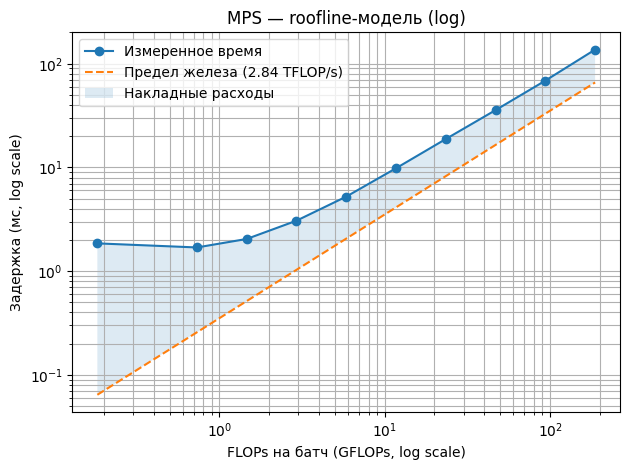

In [ ]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    from fvcore.nn import FlopCountAnalysis
    _FVCORE = True
except ImportError:
    _FVCORE = False


# Константы   

INPUT_SHAPE  = (1, 3, 48, 48)
BATCH_SIZES  = [1, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
WARMUP_ITERS = 50
TARGET_SEC   = 5.0
CLIP_PCT     = (5, 95)

PEAK_FLOPS   = 2.84e12   # FP32, M2 GPU
DTYPE        = torch.float32


# Helpers

def sync(device: str) -> None:
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def count_flops(model: torch.nn.Module) -> int:
    """MACs × 2 = FLOPs. Совместимо с пиковыми FLOP/s железа (fvcore возвращает MACs)."""
    if not _FVCORE:
        raise RuntimeError("fvcore не установлен: pip install fvcore")
    m = copy.deepcopy(model).cpu().eval()
    dummy = torch.zeros(*INPUT_SHAPE)
    return int(FlopCountAnalysis(m, dummy).total()) * 2


# Benchmark   

def run_benchmark(model: torch.nn.Module, device_name: str) -> pd.DataFrame:
    device = torch.device(device_name)
    m = copy.deepcopy(model).to(device=device, dtype=DTYPE).eval()

    flops_per_image = count_flops(m)
    rows = []

    for bs in BATCH_SIZES:
        x = torch.zeros(bs, *INPUT_SHAPE[1:], device=device, dtype=DTYPE)

        with torch.inference_mode():
            for _ in range(WARMUP_ITERS):
                m(x)
            sync(device_name)

            samples: list[float] = []
            elapsed_total = 0.0

            while elapsed_total < TARGET_SEC:
                sync(device_name)
                t0 = time.perf_counter_ns()
                m(x)
                sync(device_name)
                t1 = time.perf_counter_ns()
                ms = (t1 - t0) / 1e6
                samples.append(ms)
                elapsed_total += ms / 1000

        arr = np.array(samples, dtype=np.float64)
        lo, hi = np.percentile(arr, CLIP_PCT)
        arr = arr[(arr >= lo) & (arr <= hi)]

        flops_batch = flops_per_image * bs
        rows.append({
            "batch_size":  bs,
            "flops":       float(flops_batch),
            "time_ms":     float(np.median(arr)),
            "time_std_ms": float(np.std(arr)),
            "time_p99_ms": float(np.percentile(arr, 99)),
            "ideal_ms":    float(flops_batch / PEAK_FLOPS * 1000),
        })

    df = pd.DataFrame(rows)
    df["efficiency_pct"] = df["ideal_ms"] / df["time_ms"] * 100
    return df


# ── Analysis   ─

def analyze(df: pd.DataFrame) -> dict:
    x: np.ndarray = df["flops"].to_numpy(dtype=np.float64)
    y: np.ndarray = df["time_ms"].to_numpy(dtype=np.float64)

    a, b = np.polyfit(x, y, 1)
    y_pred: np.ndarray = a * x + b

    ss_res = float(np.sum((y - y_pred) ** 2))
    ss_tot = float(np.sum((y - float(y.mean())) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    r  = float(np.corrcoef(x, y)[0, 1])

    effective_tflops = (1.0 / a) / 1e9

    return {
        "slope_a":          a,
        "intercept_b":      b,
        "r":                r,
        "r2":               r2,
        "y_pred":           y_pred,
        "effective_tflops": effective_tflops,
        "mfu_pct":          effective_tflops / (PEAK_FLOPS / 1e12) * 100,
    }


# Plots

def plot_regression(df: pd.DataFrame, stats: dict, device_name: str) -> None:
    x_gflops: np.ndarray = df["flops"].to_numpy(dtype=np.float64) / 1e9
    y_ms: np.ndarray     = df["time_ms"].to_numpy(dtype=np.float64)
    y_std: np.ndarray    = df["time_std_ms"].to_numpy(dtype=np.float64)

    a, b = float(stats["slope_a"]), float(stats["intercept_b"])
    x_line = np.linspace(x_gflops.min(), x_gflops.max(), 300)
    y_line = a * (x_line * 1e9) + b

    plt.figure()
    plt.errorbar(x_gflops, y_ms, yerr=y_std, fmt="o", label="Медиана ± std")
    plt.plot(x_line, y_line, label=f"Линейная аппроксимация (R²={stats['r2']:.4f})")
    plt.xlabel("FLOPs на батч (GFLOPs)")
    plt.ylabel("Задержка (мс)")
    plt.title(f"{device_name.upper()} — линейная регрессия")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


def plot_roofline(df: pd.DataFrame, stats: dict, device_name: str) -> None:
    x: np.ndarray        = df["flops"].to_numpy(dtype=np.float64) / 1e9
    y_real: np.ndarray   = df["time_ms"].to_numpy(dtype=np.float64)
    y_ideal: np.ndarray  = df["ideal_ms"].to_numpy(dtype=np.float64)

    plt.figure()
    plt.plot(x, y_real,  marker="o", label="Измеренное время")
    plt.plot(x, y_ideal, linestyle="--", label=f"Предел железа ({PEAK_FLOPS/1e12:.2f} TFLOP/s)")
    plt.fill_between(x, y_ideal, y_real, alpha=0.15, label="Накладные расходы")

    plt.yscale("log")
    plt.xscale("log")

    plt.xlabel("FLOPs на батч (GFLOPs, log scale)")
    plt.ylabel("Задержка (мс, log scale)")
    plt.title(f"{device_name.upper()} — roofline-модель (log)")
    plt.legend()
    plt.grid(True, which="both")  # лучше для лог шкалы
    plt.tight_layout()
    plt.show()


# Запуск 

device_name = "mps"

df    = run_benchmark(model, device_name)
stats = analyze(df)

print(f"Устройство:          {device_name.upper()}")
print(f"Эфф. пропускная сп.: {stats['effective_tflops']:.3f} TFLOP/s")
print(f"MFU:                 {stats['mfu_pct']:.1f}%")
print(f"Pearson r:           {stats['r']:.4f}")
print(f"R²:                  {stats['r2']:.4f}")
print()
print(df[["batch_size", "time_ms", "time_std_ms", "time_p99_ms",
          "ideal_ms", "efficiency_pct"]].to_string(index=False))

plot_regression(df, stats, device_name)
plot_roofline(df, stats, device_name)

In [12]:
import numpy as np
import time

N = 2000
A = np.random.rand(N, N).astype(np.float32)
B = np.random.rand(N, N).astype(np.float32)

start = time.time()
C = A @ B
end = time.time()

ops = 2 * N**3
tflops = ops / (end - start) / 1e12

print(f"TFLOPS: {tflops}")

TFLOPS: 1.0220350278700008


## Измерение памяти
1) Измеряем с помощью **Metal** 
2) Измеряем инференс на **CPU** используя `psutil`

In [121]:
# реальный размер модели через storage (параметры + буферы, без двойного счёта)
seen = set()
total = 0

for t in list(model.parameters()) + list(model.buffers()):
    s = t.untyped_storage()
    if s.data_ptr() not in seen:
        seen.add(s.data_ptr())
        total += s.nbytes()

print(f"Вес модели: {total / 1024**2:.4f} MiB")
input = 3 * 48 * 48 * 4
print(f"Вес со входом: {((total+input) / 1024**2):.4f} MiB")

Вес модели: 16.5490 MiB
Вес со входом: 16.5754 MiB


Вес модели: 16.55 MiB
 batch  real_total_mib  theory_total_mib
     1          16.827            16.572
     4          17.108            16.651
     8          17.108            16.757
    16          17.499            16.967
    32          21.046            17.389
    64          25.546            18.233
   128          34.546            19.921
   256          34.546            23.296


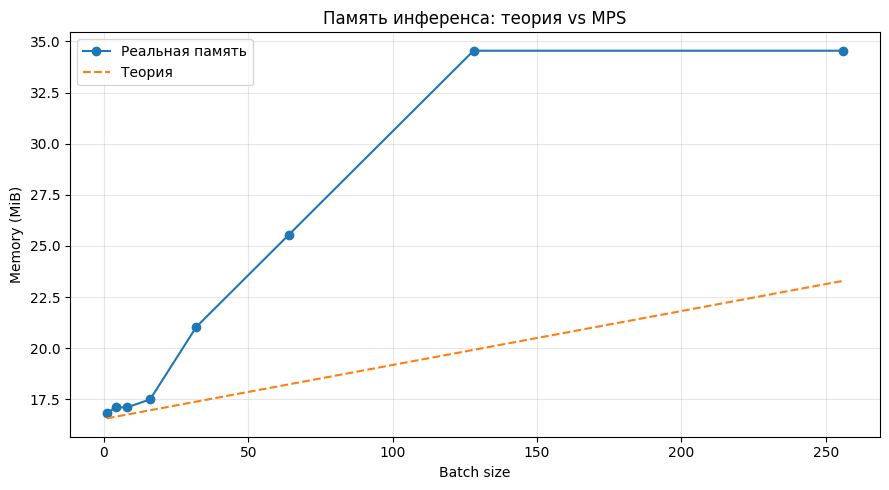

In [127]:
# mps
import torch
import pandas as pd
import matplotlib.pyplot as plt

device = "mps"
model = model.to(device).eval()
dtype_bytes = torch.tensor([], dtype=torch.float32).element_size()

def sync():
    torch.mps.synchronize()

def model_bytes(m):
    return sum(p.numel() * p.element_size() for p in m.parameters())

def input_bytes(batch_size):
    return batch_size * 3 * 48 * 48 * dtype_bytes

def mib(n_bytes):
    return n_bytes / (1024 ** 2)

weights_bytes = model_bytes(model)
batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256]

def measure(batch_size, runs=50):
    x = torch.randn(batch_size, 3, 48, 48, device=device)

    torch.mps.empty_cache()
    sync()

    baseline = torch.mps.current_allocated_memory()
    peak = baseline

    with torch.inference_mode():
        for _ in range(runs):
            _ = model(x)
            sync()
            cur = torch.mps.current_allocated_memory()
            if cur > peak:
                peak = cur

    delta = peak - baseline
    theory_delta = input_bytes(batch_size)

    return {
        "batch": batch_size,
        "delta_bytes": delta,
        "theory_bytes": theory_delta,
    }

rows = [measure(bs) for bs in batch_sizes]
df = pd.DataFrame(rows)

df["real_mib"] = df["delta_bytes"].map(mib)
df["theory_mib"] = df["theory_bytes"].map(mib)
df["real_total_mib"] = df["real_mib"] + mib(weights_bytes)
df["theory_total_mib"] = df["theory_mib"] + mib(weights_bytes)

print(f"Вес модели: {mib(weights_bytes):.2f} MiB")
print(df[["batch", "real_total_mib", "theory_total_mib"]].to_string(index=False, float_format=lambda v: f"{v:.3f}"))

plt.figure(figsize=(9, 5))
plt.plot(df["batch"], df["real_total_mib"], marker="o", label="Реальная память")
plt.plot(df["batch"], df["theory_total_mib"], linestyle="--", label="Теория")
plt.xlabel("Batch size")
plt.ylabel("Memory (MiB)")
plt.title("Память инференса: теория vs MPS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Вес модели: 16.55 MiB
 batch  real_total_mib  theory_total_mib
     1          23.280            16.572
     4          33.702            16.651
     8          38.483            16.757
    16          30.014            16.967
    32          34.608            17.389
    64          34.561            18.233
   128         106.905            19.921
   256         196.592            23.296


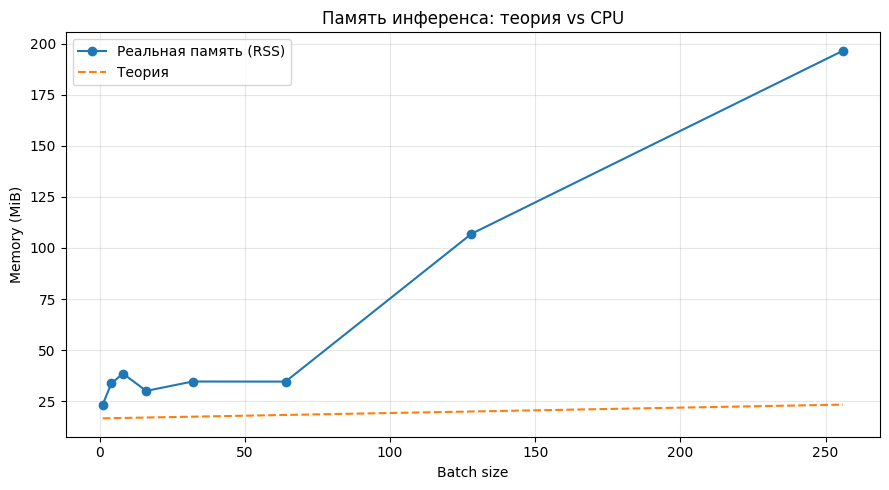

In [8]:
# cpu
import gc

import psutil
import torch
import pandas as pd
import matplotlib.pyplot as plt

# Фиксируем потоки для стабильности замеров
torch.set_num_threads(8)

device = "cpu"
model = model.to(device).eval()
process = psutil.Process()

dtype_bytes = torch.tensor([], dtype=torch.float32).element_size()

def model_bytes(m):
    return sum(p.numel() * p.element_size() for p in m.parameters())

def input_bytes(batch_size):
    return batch_size * 3 * 48 * 48 * dtype_bytes

def mib(n_bytes):
    return n_bytes / (1024 ** 2)

def rss_bytes():
    return process.memory_info().rss

weights_bytes = model_bytes(model)
batch_sizes = [1, 4, 8, 16, 32, 64, 128, 256]

def measure(batch_size, runs=50, warmup=10):
    gc.collect()
    
    # Замеряем базовую память ДО создания тензора x
    baseline = rss_bytes()
    
    # Теперь создание x попадет в дельту
    x = torch.randn(batch_size, 3, 48, 48, device=device)

    peak = baseline

    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(x)

        # Делаем один замер после всех итераций, а не каждый раз
        for _ in range(runs):
            _ = model(x)
        
        cur = rss_bytes()
        if cur > peak:
            peak = cur

    delta = peak - baseline
    theory_delta = input_bytes(batch_size)

    return {
        "batch": batch_size,
        "delta_bytes": delta,
        "theory_bytes": theory_delta,
    }

rows = [measure(bs) for bs in batch_sizes]
df = pd.DataFrame(rows)

df["real_mib"] = df["delta_bytes"].map(mib)
df["theory_mib"] = df["theory_bytes"].map(mib)
df["real_total_mib"] = df["real_mib"] + mib(weights_bytes)
df["theory_total_mib"] = df["theory_mib"] + mib(weights_bytes)

print(f"Вес модели: {mib(weights_bytes):.2f} MiB")
print(df[["batch", "real_total_mib", "theory_total_mib"]].to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# График в оригинальном стиле (линии, без заливки)
plt.figure(figsize=(9, 5))
plt.plot(df["batch"], df["real_total_mib"], marker="o", label="Реальная память (RSS)")
plt.plot(df["batch"], df["theory_total_mib"], linestyle="--", label="Теория")
plt.xlabel("Batch size")
plt.ylabel("Memory (MiB)")
plt.title("Память инференса: теория vs CPU")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Функция потерь, оптимизатор и планировщик

### Кросс-энтропийная функция потерь

Для задачи классификации на $K$ классов используем **Categorical Cross-Entropy**:

$$\mathcal{L} = -\frac{1}{N} \sum_{n=1}^{N} \sum_{k=1}^{K} y_{nk} \log \hat{p}_{nk}$$

где $\hat{p}_{nk} = \text{softmax}(z_{nk}) = \frac{e^{z_{nk}}}{\sum_j e^{z_{nj}}}$

### Оптимизатор Adam (сокращение от Adaptive Moment Estimation)

Adam адаптирует learning rate для каждого параметра:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\theta_t = \theta_{t-1} - \frac{\alpha \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

### Cosine Annealing

Планировщик плавно снижает LR по косинусному закону:

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min}) \left(1 + \cos\left(\frac{T_{cur} \pi}{T_{max}}\right) \right)$$

### Cosine Annealing с рестартами

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{T_{cur}}{T_{i}}\pi\right)\right)$$
When $T_{cur}=T_{i}$, set $\eta_t = \eta_{min}$. When $T_{cur}=0$ after restart, set $\eta_t=\eta_{max}$.

#### Будем использовать обычный отжиг для большей стабильности обучения 

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing улучшает обобщение
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-5) # без рестартов

# scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts( #! С рестартами
#     optimizer, 
#     T_0=10,       # Первый цикл 10 эпох
#     T_mult=2,     # Каждый следующий в 2 раза длиннее
#     eta_min=1e-5
# )

print('Функция потерь: CrossEntropyLoss с label_smoothing=0.1')
print('Оптимизатор:   Adam (lr=1e-3, weight_decay=1e-4)')
print('Планировщик:   CosineAnnealingLR (T_max=30)')

Функция потерь: CrossEntropyLoss с label_smoothing=0.1
Оптимизатор:   Adam (lr=1e-3, weight_decay=1e-4)
Планировщик:   CosineAnnealingLR (T_max=30)


## Цикл обучения

Обучаем `NUM_EPOCHS` эпох. На каждой эпохе:
1. **Forward pass** вычисляем предсказания
2. **Loss** считаем кросс-энтропию
3. **Backward pass backpropagation**
4. **Optimizer step** обновляем веса
5. **Validation** оцениваем на тестовой выборке

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total


NUM_EPOCHS = 25
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, test_loader, criterion)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)

    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), 'best_rtsd_cnn.pth')

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}]  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%  |  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.2f}%  |  LR: {current_lr:.6f}')

print(f'\nЛучшая точность на тесте: {best_acc:.2f}%')


Лучшая точность на тесте: 0.00%


## Графики обучения

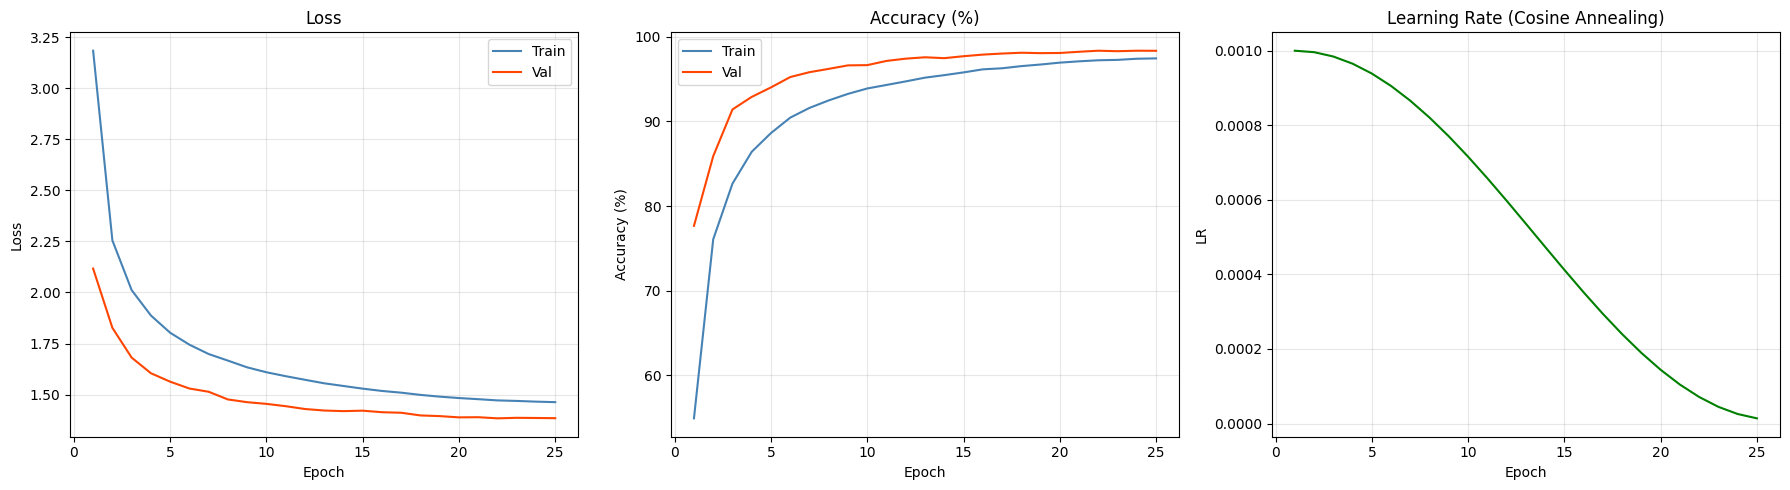

In [11]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='orangered')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train', color='steelblue')
axes[1].plot(epochs, history['val_acc'],   label='Val',   color='orangered')
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(epochs, history['lr'], color='green')
axes[2].set_title('Learning Rate (Cosine Annealing)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Оценка: Точность по классам и Confusion Matrix

In [10]:
# Загружаем лучшие веса
model.load_state_dict(torch.load('best_rtsd_cnn.pth', map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Точность по классам
from collections import defaultdict
class_correct = defaultdict(int)
class_total   = defaultdict(int)

for p, l in zip(all_preds, all_labels):
    class_total[l] += 1
    if p == l:
        class_correct[l] += 1

# Топ-10 худших классов
class_acc = {c: 100 * class_correct[c] / class_total[c]
             for c in class_total if class_total[c] > 0}
worst_classes = sorted(class_acc.items(), key=lambda x: x[1])[:10]

print('Топ-10 классов с наихудшей точностью:')
for cls_id, acc in worst_classes:
    print(f'  [{cls_id:3d}] {CLASS_NAMES[cls_id]}: {acc:.1f}%  (n={class_total[cls_id]})')

overall_acc = 100 * np.mean(all_preds == all_labels)
print(f'\nОбщая точность: {overall_acc:.2f}%')

Топ-10 классов с наихудшей точностью:
  [10107] 12988: 0.0%  (n=2)
  [14502] 1985: 0.0%  (n=2)
  [5266] 10680: 0.0%  (n=1)
  [4076] 1005: 0.0%  (n=1)
  [4031] 12985: 0.0%  (n=3)
  [15627] 14519: 0.0%  (n=1)
  [14434] 1364: 0.0%  (n=1)
  [14913] 7429: 0.0%  (n=1)
  [4006] 15595: 0.0%  (n=2)
  [1420] 11337: 0.0%  (n=2)

Общая точность: 98.37%


## Исследование устойчивости к искажениям

Проверяем, как падает точность при различных типах искажений:
- **Gaussian Noise** — случайный шум (имитирует плохую камеру)
- **Gaussian Blur** — размытие (имитирует расфокусировку)
- **Occlusion** — случайное прямоугольное закрытие части знака

In [11]:
def add_gaussian_noise(images, sigma=0.1):
    """Добавляем белый гауссовский шум."""
    noise = torch.randn_like(images) * sigma
    return torch.clamp(images + noise, -3, 3)


def add_blur(images, kernel_size=5):
    """Применяем гауссовское размытие через свёрточный фильтр."""
    # Создаём гауссово ядро
    sigma = 1.5
    x = torch.arange(kernel_size).float() - kernel_size // 2
    gauss = torch.exp(-x**2 / (2 * sigma**2))
    gauss = gauss / gauss.sum()
    kernel = gauss.outer(gauss).unsqueeze(0).unsqueeze(0)
    kernel = kernel.expand(3, 1, -1, -1).to(images.device)
    pad = kernel_size // 2
    return nn.functional.conv2d(images, kernel, padding=pad, groups=3)


def add_occlusion(images, patch_size=12):
    """Закрываем случайную область нулями (имитация стикера/загрязнения)."""
    imgs = images.clone()
    B, C, H, W = imgs.shape
    for i in range(B):
        x = np.random.randint(0, W - patch_size)
        y = np.random.randint(0, H - patch_size)
        imgs[i, :, y:y+patch_size, x:x+patch_size] = 0
    return imgs


def evaluate_with_distortion(model, loader, distortion_fn):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            images_dist = distortion_fn(images)
            outputs = model(images_dist)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total


print('Оцениваем устойчивость модели...')
acc_clean  = evaluate_with_distortion(model, test_loader, lambda x: x)
acc_noise1 = evaluate_with_distortion(model, test_loader, lambda x: add_gaussian_noise(x, 0.1))
acc_noise2 = evaluate_with_distortion(model, test_loader, lambda x: add_gaussian_noise(x, 0.3))
acc_blur1  = evaluate_with_distortion(model, test_loader, lambda x: add_blur(x, 3))
acc_blur2  = evaluate_with_distortion(model, test_loader, lambda x: add_blur(x, 7))
acc_occ1   = evaluate_with_distortion(model, test_loader, lambda x: add_occlusion(x, 8))
acc_occ2   = evaluate_with_distortion(model, test_loader, lambda x: add_occlusion(x, 16))

results = {
    'Чистые данные': acc_clean,
    'Шум σ=0.1':     acc_noise1,
    'Шум σ=0.3':     acc_noise2,
    'Blur 3×3':      acc_blur1,
    'Blur 7×7':      acc_blur2,
    'Окклюзия 8px':  acc_occ1,
    'Окклюзия 16px': acc_occ2,
}

print('\nПрофиль устойчивости:')
for name, acc in results.items():
    drop = acc_clean - acc
    bar = '█' * int(acc / 2)
    print(f'  {name:<20s}: {acc:5.2f}%  (Δ = -{drop:.2f}%)')

Оцениваем устойчивость модели...

Профиль устойчивости:
  Чистые данные       : 98.37%  (Δ = -0.00%)
  Шум σ=0.1           : 98.28%  (Δ = -0.10%)
  Шум σ=0.3           : 96.95%  (Δ = -1.42%)
  Blur 3×3            : 98.18%  (Δ = -0.19%)
  Blur 7×7            : 97.81%  (Δ = -0.57%)
  Окклюзия 8px        : 96.91%  (Δ = -1.46%)
  Окклюзия 16px       : 89.60%  (Δ = -8.77%)


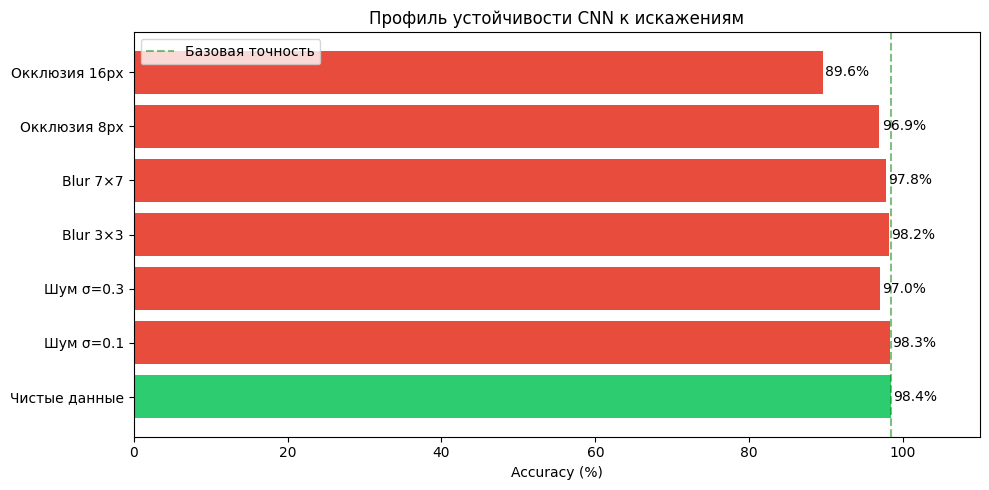

In [12]:
# Визуализация профиля устойчивости
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = list(results.values())
colors = ['#2ecc71'] + ['#e74c3c'] * (len(names) - 1)

bars = ax.barh(names, accs, color=colors)
ax.axvline(x=acc_clean, color='green', linestyle='--', alpha=0.5, label='Базовая точность')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)')
ax.set_title('Профиль устойчивости CNN к искажениям')
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

## Эксперимент: Сравнение функций активации

Обучим три версии модели с разными активациями и сравним:
- **ReLU** — стандарт для CNN
- **LeakyReLU** — устраняет проблему мёртвых нейронов
- **Sigmoid** — устаревшая (демонстрация ванишинг-градиента)

In [15]:
def quick_train(activation, epochs=10):
    """Быстрое обучение для сравнения активаций."""
    m = RTSD_CNN(num_classes=NUM_CLASSES, activation=activation).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    val_accs = []
    for ep in range(epochs):
        train_epoch(m, train_loader, crit, opt)
        _, va = eval_epoch(m, test_loader, crit)
        val_accs.append(va)
        sched.step()
        print(f'  [{activation}] Epoch {ep+1}/{epochs}: Val Acc = {va:.2f}%')
    return val_accs, m

print('Сравниваем функции активации (10 эпох каждая)...')
relu_accs,   _ = quick_train('relu',    epochs=10)
leaky_accs,  _ = quick_train('leaky',   epochs=10)
sigm_accs,   _ = quick_train('sigmoid', epochs=10)

Сравниваем функции активации (10 эпох каждая)...
  [relu] Epoch 1/10: Val Acc = 78.03%
  [relu] Epoch 2/10: Val Acc = 86.04%
  [relu] Epoch 3/10: Val Acc = 90.10%
  [relu] Epoch 4/10: Val Acc = 92.89%
  [relu] Epoch 5/10: Val Acc = 94.29%
  [relu] Epoch 6/10: Val Acc = 95.12%
  [relu] Epoch 7/10: Val Acc = 95.95%
  [relu] Epoch 8/10: Val Acc = 96.26%
  [relu] Epoch 9/10: Val Acc = 96.73%
  [relu] Epoch 10/10: Val Acc = 96.77%
  [leaky] Epoch 1/10: Val Acc = 77.25%
  [leaky] Epoch 2/10: Val Acc = 85.63%
  [leaky] Epoch 3/10: Val Acc = 89.63%
  [leaky] Epoch 4/10: Val Acc = 91.42%
  [leaky] Epoch 5/10: Val Acc = 93.66%
  [leaky] Epoch 6/10: Val Acc = 94.67%
  [leaky] Epoch 7/10: Val Acc = 95.76%
  [leaky] Epoch 8/10: Val Acc = 96.13%
  [leaky] Epoch 9/10: Val Acc = 96.56%
  [leaky] Epoch 10/10: Val Acc = 96.59%
  [sigmoid] Epoch 1/10: Val Acc = 32.27%
  [sigmoid] Epoch 2/10: Val Acc = 38.64%
  [sigmoid] Epoch 3/10: Val Acc = 44.64%
  [sigmoid] Epoch 4/10: Val Acc = 48.30%
  [sigmoid] Epo

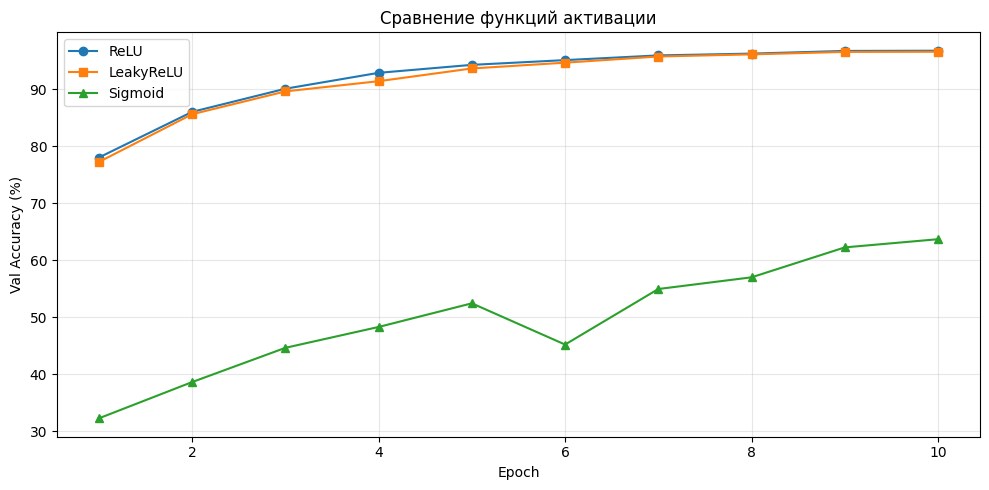

ReLU    финальная Val Acc: 96.77%
Leaky   финальная Val Acc: 96.59%
Sigmoid финальная Val Acc: 63.70%


In [16]:
ep_range = range(1, 11)
plt.figure(figsize=(10, 5))
plt.plot(ep_range, relu_accs,  label='ReLU',       marker='o')
plt.plot(ep_range, leaky_accs, label='LeakyReLU',  marker='s')
plt.plot(ep_range, sigm_accs,  label='Sigmoid',    marker='^')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy (%)')
plt.title('Сравнение функций активации')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ReLU    финальная Val Acc: {relu_accs[-1]:.2f}%')
print(f'Leaky   финальная Val Acc: {leaky_accs[-1]:.2f}%')
print(f'Sigmoid финальная Val Acc: {sigm_accs[-1]:.2f}%')

## Визуализация: Saliency Map (Gradient-based)

**Saliency Map** показывает, какие пиксели изображения сильнее всего влияют на предсказание модели.

Вычисляется как градиент скора класса по входному изображению:

$$S = \left|\frac{\partial \text{score}_c}{\partial x}\right|$$

Большие значения → пиксели важны для решения.

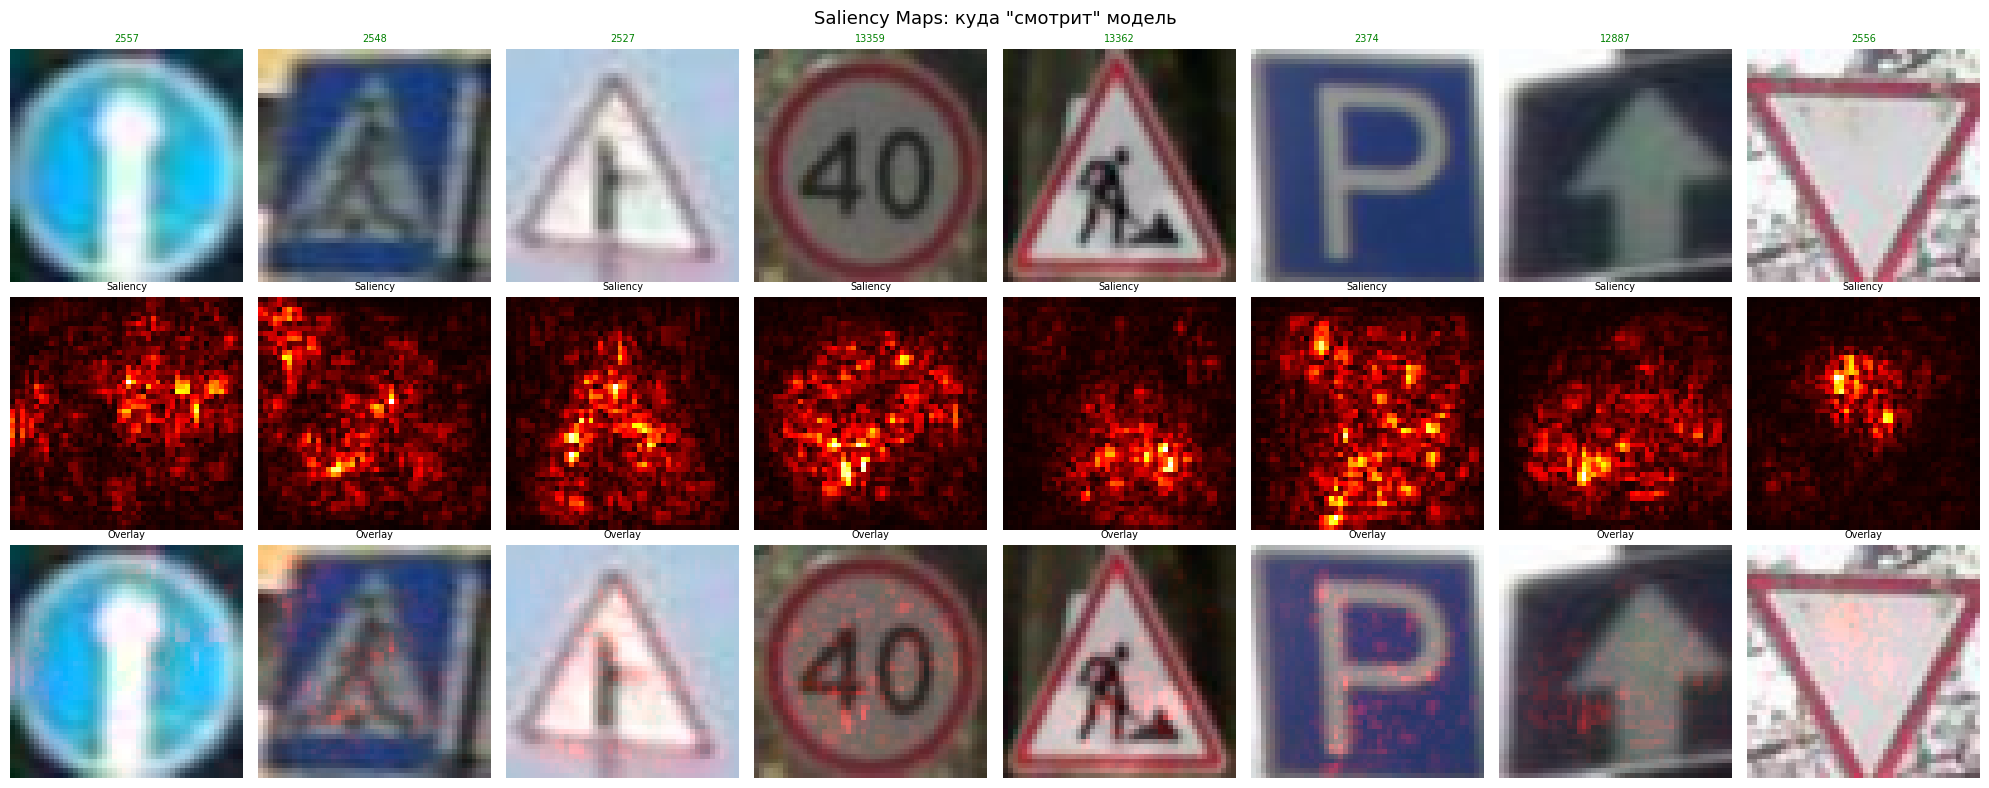

In [11]:
def compute_saliency(model, image_tensor, label):
    """Вычисляем saliency map через градиенты."""
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad_(True)

    output = model(image_tensor)
    score = output[0, label]
    model.zero_grad()
    score.backward()

    saliency = image_tensor.grad.data.abs()
    saliency, _ = saliency.max(dim=1)
    return saliency.squeeze().cpu().numpy()


# Загружаем лучшую модель
model.load_state_dict(torch.load('best_rtsd_cnn.pth', map_location=device))

# Берём несколько примеров из тест-сета
test_dataset_raw = test_dataset
indices = np.random.choice(len(test_dataset_raw), 8, replace=False)

fig, axes = plt.subplots(3, 8, figsize=(20, 8))

for col, idx in enumerate(indices):
    img_tensor, label = test_dataset_raw[idx]

    # Предсказание
    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(device))
        pred = out.argmax(1).item()

    # Saliency
    saliency = compute_saliency(model, img_tensor, label)

    # Оригинальное изображение
    img_show = denormalize(img_tensor).permute(1,2,0).numpy()

    axes[0, col].imshow(img_show)
    color = 'green' if pred == label else 'red'
    axes[0, col].set_title(str(CLASS_NAMES[pred])[:12], color=color, fontsize=7)  # str()
    axes[0, col].axis('off')

    # Saliency map
    axes[1, col].imshow(saliency, cmap='hot')
    axes[1, col].set_title('Saliency', fontsize=7)
    axes[1, col].axis('off')

    # Наложение
    sal_norm = (saliency - saliency.min()) / (saliency.max() + 1e-8)
    overlay = img_show.copy()
    overlay[:,:,0] = np.clip(overlay[:,:,0] + sal_norm * 0.5, 0, 1)
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Overlay', fontsize=7)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Изображение', fontsize=9)
axes[1, 0].set_ylabel('Saliency',   fontsize=9)
axes[2, 0].set_ylabel('Наложение',  fontsize=9)

plt.suptitle('Saliency Maps: куда "смотрит" модель', fontsize=13)
plt.tight_layout()
plt.show()

## Grad-CAM визуализация

**Grad-CAM** (Gradient-weighted Class Activation Mapping) — более мощный метод визуализации. Использует градиенты относительно **feature maps последнего свёрточного слоя**:

$$\alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$$

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$

Это «тепловая карта» активаций — показывает, какие **регионы** изображения важны.

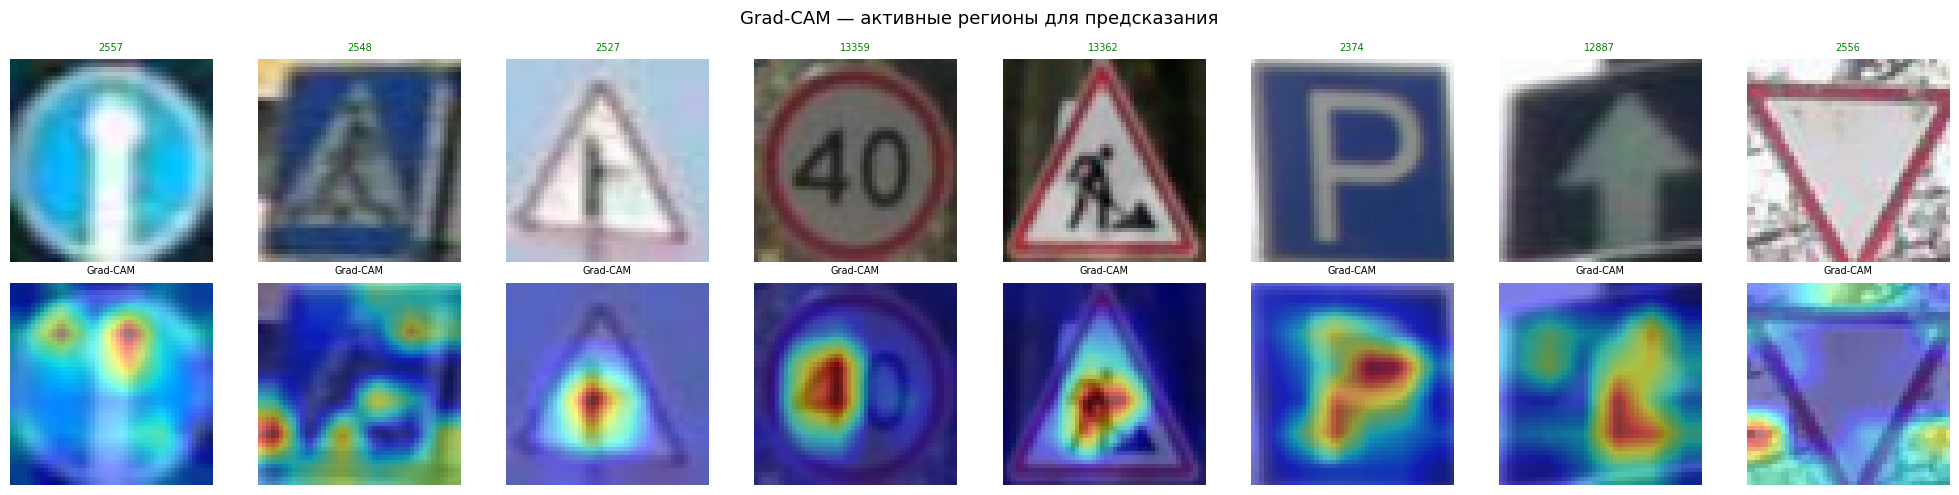

In [12]:
class GradCAM:
    """Grad-CAM для последнего сверточного блока."""
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        # Хуки для захвата активаций и градиентов
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        x = x.unsqueeze(0).to(device)
        x.requires_grad_(True)

        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Взвешенная сумма активаций
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # GAP по пространству
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)
        cam = torch.nn.functional.interpolate(
            cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam, class_idx


# Инициализируем Grad-CAM на последнем сверточном слое block3
gradcam = GradCAM(model, model.block3[-2])  # последний Conv2d в block3

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for col, idx in enumerate(indices):
    img_tensor, label = test_dataset_raw[idx]
    cam, pred = gradcam(img_tensor, class_idx=label)

    img_show = denormalize(img_tensor).permute(1,2,0).numpy()

    # Оригинал
    axes[0, col].imshow(img_show)
    color = 'green' if pred == label else 'red'
    axes[0, col].set_title(CLASS_NAMES[label][:12], color=color, fontsize=7)
    axes[0, col].axis('off')

    # Grad-CAM overlay
    import matplotlib.cm as cm_module
    heatmap = cm_module.jet(cam)[:,:,:3]
    overlay = 0.5 * img_show + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    axes[1, col].imshow(overlay)
    axes[1, col].set_title('Grad-CAM', fontsize=7)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Оригинал', fontsize=9)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=9)

plt.suptitle('Grad-CAM — активные регионы для предсказания', fontsize=13)
plt.tight_layout()
plt.show()

## Анализ ошибок: что путает модель

Найдём примеры, где модель наиболее уверенно ошибается.

Ошибок: 9 из 500 (1.8%)


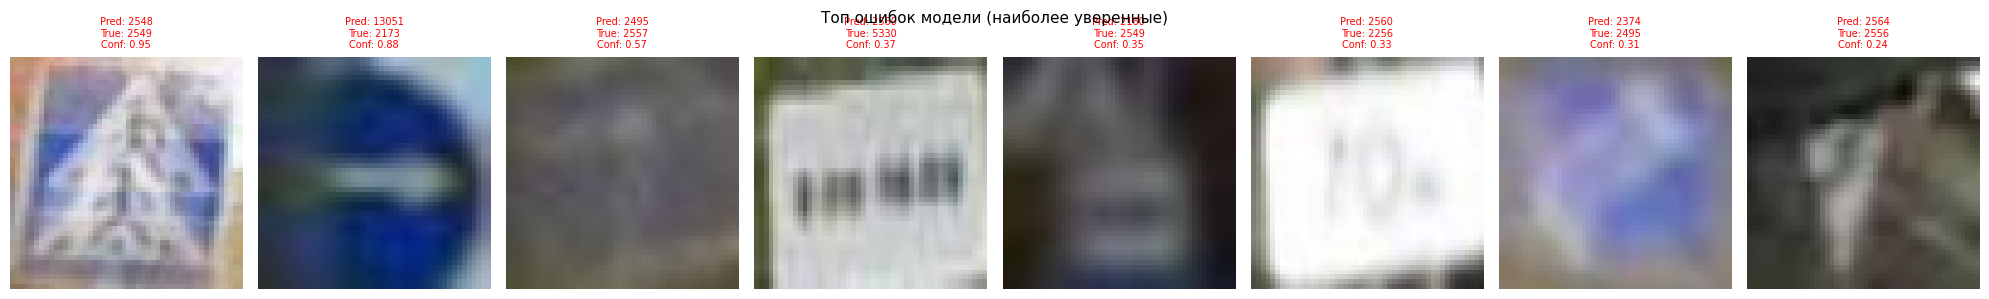

In [20]:
import torch.nn.functional as F

model.eval()
wrong_examples = []  # (confidence, img_tensor, true_label, pred_label)

with torch.no_grad():
    for i in range(min(500, len(test_dataset_raw))):
        img, label = test_dataset_raw[i]
        out = model(img.unsqueeze(0).to(device))
        probs = F.softmax(out, dim=1)
        conf, pred = probs.max(1)
        pred = pred.item()
        if pred != label:
            wrong_examples.append((conf.item(), img, label, pred))

# Сортируем по уверенности (самые уверенные ошибки)
wrong_examples.sort(key=lambda x: -x[0])
print(f'Ошибок: {len(wrong_examples)} из 500 ({100*len(wrong_examples)/500:.1f}%)')

# Показываем топ-8 самых уверенных ошибок
n_show = min(8, len(wrong_examples))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(2.5*n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, (conf, img, true_l, pred_l) in zip(axes, wrong_examples[:n_show]):
        img_show = denormalize(img).permute(1,2,0).numpy()
        ax.imshow(img_show)
        ax.set_title(
            f'Pred: {CLASS_NAMES[pred_l][:10]}\n'
            f'True: {CLASS_NAMES[true_l][:10]}\n'
            f'Conf: {conf:.2f}',
            color='red', fontsize=7
        )
        ax.axis('off')
    plt.suptitle('Топ ошибок модели (наиболее уверенные)', fontsize=11)
    plt.tight_layout()
    plt.show()

# ============================================================
# Интерактивный блок
# ============================================================

In [14]:
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
import torch.nn.functional as F

upload = widgets.FileUpload(accept='image/*', multiple=False, description='Выбери фото')
out    = widgets.Output()

def on_upload(change):
    with out:
        clear_output(wait=True)

        # Читаем загруженный файл
        uploaded_file = upload.value[0]                      # tuple → берём первый элемент
        img_bytes = uploaded_file['content']                 # bytes напрямую
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        # Предобработка (те же трансформации что и для теста)
        tensor = transform_test(img).unsqueeze(0).to(device)

        # Предсказание
        model.eval()
        with torch.no_grad():
            logits = model(tensor)
            probs  = F.softmax(logits, dim=1)

        top5_probs, top5_ids = probs[0].topk(5)
        top5_probs = top5_probs.cpu().numpy()
        top5_ids   = top5_ids.cpu().numpy()

        # Grad-CAM для загруженного изображения
        tensor_cam = transform_test(img).to(device)
        cam, pred_idx = gradcam(tensor_cam, class_idx=top5_ids[0])

        # --- Визуализация ---
        img_show = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0

        heatmap = plt.cm.jet(cam)[:, :, :3]
        overlay = np.clip(0.5 * img_show + 0.5 * heatmap, 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(img_show)
        axes[0].set_title('Оригинал', fontsize=11)
        axes[0].axis('off')

        axes[1].imshow(cam, cmap='hot')
        axes[1].set_title('Saliency (heat)', fontsize=11)
        axes[1].axis('off')

        axes[2].imshow(overlay)
        axes[2].set_title('Grad-CAM overlay', fontsize=11)
        axes[2].axis('off')

        pred_name = str(CLASS_NAMES[top5_ids[0]])
        fig.suptitle(f'Предсказание: {pred_name}  ({top5_probs[0]*100:.1f}%)',
                     fontsize=13, fontweight='bold', color='green')
        plt.tight_layout()
        plt.show()

        # Топ-5 классов
        print('─' * 40)
        print('Топ-5 предсказаний:')
        for i, (cls_id, prob) in enumerate(zip(top5_ids, top5_probs)):
            bar = '█' * int(prob * 30)
            print(f'  {i+1}. {str(CLASS_NAMES[cls_id]):<15} {prob*100:5.1f}%  {bar}')
        print('─' * 40)
        
        # случайных примера из датасета с предсказанным классом
        print(f'\nПримеры знака «{pred_name}» из датасета:')

        # Ищем индексы с нужным классом в тест-сете
        matching_indices = [
            i for i in range(len(test_dataset_raw))
            if test_dataset_raw[i][1] == top5_ids[0]
        ]

        if len(matching_indices) == 0:
            print('  (примеры не найдены в тест-сете)')
        else:
            sample_indices = np.random.choice(
                matching_indices,
                size=min(3, len(matching_indices)),
                replace=False
            )

            fig2, axes2 = plt.subplots(1, len(sample_indices), figsize=(9, 3))
            if len(sample_indices) == 1:
                axes2 = [axes2]

            for ax, si in zip(axes2, sample_indices):
                ex_tensor, _ = test_dataset_raw[si]
                ex_img = denormalize(ex_tensor).permute(1, 2, 0).numpy()
                ax.imshow(ex_img)
                ax.set_title(f'пример #{si}', fontsize=9)
                ax.axis('off')

            fig2.suptitle(f'Примеры «{pred_name}» из датасета', fontsize=11)
            plt.tight_layout()
            plt.show()

upload.observe(on_upload, names='value')

display(widgets.VBox([
    widgets.Label('Загрузить фотографию:'),
    upload,
    out
]))